# LieselVI: basic variational inference

This notebook mirrors the basic `LieselOptim` tutorial with a single-sample-size Gaussian regression model. Instead of optimizing model parameters directly, `LieselVI` optimizes the parameters of an approximate posterior distribution. We first fit a full-data diagonal Gaussian variational approximation, then add a train/test split and mini-batches. ELBO losses do not use validation data, so the split keeps only held-out test observations.

## Imports

In [1]:
import logging

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.experimental.optim as opt
import liesel.model as lsl

logging.getLogger("liesel.model.model").setLevel(logging.WARNING)
pd.options.display.float_format = "{:.3f}".format

## Simulate one data set

The response `y` and design matrix `X` both use axis `0` as their observation axis. This is the simplest case for splitting and batching because every observed array has the same sample size.

In [2]:
rng = np.random.default_rng(202407)

n = 240
x = rng.uniform(-2.0, 2.0, size=n)
X = np.column_stack([np.ones(n), x])

beta_true = np.array([0.7, -1.4])
sigma_true = 0.6
y = X @ beta_true + rng.normal(scale=sigma_true, size=n)

{
    "n": n,
    "beta_true": beta_true.tolist(),
    "sigma_true": sigma_true,
    "y_mean": float(y.mean()),
}

{'n': 240,
 'beta_true': [0.7, -1.4],
 'sigma_true': 0.6,
 'y_mean': 0.5845723002428674}

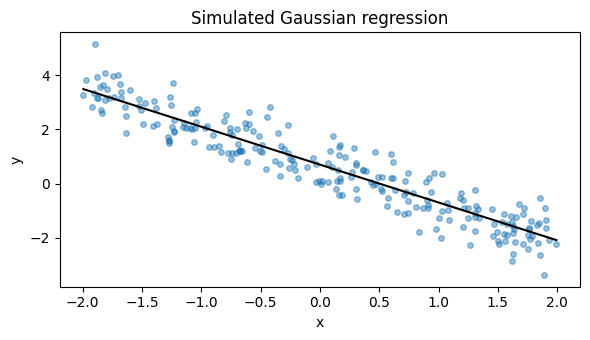

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(x, y, s=16, alpha=0.45)
x_line = np.linspace(x.min(), x.max(), 100)
X_line = np.column_stack([np.ones_like(x_line), x_line])
ax.plot(x_line, X_line @ beta_true, color="black", linewidth=1.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Simulated Gaussian regression")
plt.tight_layout()
plt.show()

## Build the model

The model has two target parameters: a vector of regression coefficients `beta` and the unconstrained scale parameter `log_sigma`. The standard deviation used in the likelihood is `sigma = exp(log_sigma)`.

In [4]:
X_jax = jnp.asarray(X)
y_jax = jnp.asarray(y)

beta = lsl.Var.new_param(
    jnp.zeros(X_jax.shape[1]),
    lsl.Dist(tfd.Normal, loc=0.0, scale=5.0),
    name="beta",
)
log_sigma = lsl.Var.new_param(
    jnp.array(0.0),
    lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="log_sigma",
)
sigma = lsl.Var.new_calc(jnp.exp, log_sigma, name="sigma")
X_var = lsl.Var.new_obs(X_jax, name="X")
mu = lsl.Var.new_calc(lambda X, beta: X @ beta, X_var, beta, name="mu")
y_var = lsl.Var.new_obs(
    y_jax,
    lsl.Dist(tfd.Normal, loc=mu, scale=sigma),
    name="y",
)

model = lsl.Model([y_var])
{
    "parameters": list(model.parameters),
    "observed": list(model.observed),
}

{'parameters': ['log_sigma', 'beta'], 'observed': ['X', 'y']}

## Full-data diagonal Gaussian VI

`NegElboLoss.mvn_diag()` constructs a diagonal multivariate normal approximation over all target parameters. We pass this loss to `LieselVI`, use a moderately aggressive Adam optimizer, and keep the batch configuration at full data.

In [5]:
loss_full = opt.NegElboLoss.mvn_diag(
    model,
    nsamples=5,
    scale=True,
    scale_diag=0.2,
)
full_schedule = optax.exponential_decay(
    init_value=2e-2,
    transition_steps=60,
    decay_rate=0.95,
    end_value=1e-3,
)
full_optimizer = opt.Optimizer(
    list(loss_full.q.parameters),
    optax.adam(full_schedule),
    identifier="full_vi_adam",
)

full_engine = opt.LieselVI(
    model,
    loss=loss_full,
    optimizers=[full_optimizer],
    stopper=opt.Stopper(epochs=350, patience=60, rtol=1e-4),
    seed=11,
).build_engine()

{
    "q_parameters": list(full_engine.loss.q.parameters),
    "batching": repr(full_engine.batches),
    "optimizer_ids": [optimizer.identifier for optimizer in full_engine.optimizers],
}

{'q_parameters': ['(beta|log_sigma)_loc', 'h((beta|log_sigma)_scale)'],
 'batching': 'Batches(n=240, batch_size=240, default_axis=0)',
 'optimizer_ids': ['full_vi_adam']}

In [6]:
result_full = full_engine.fit()
result_full

Training loss: 0.951, Monitoring loss: 0.951:  62%|██████▏   | 217/350 [00:00<00:00, 302.74it/s]


OptimResult(final_epoch=217, best_epoch=157, duration=0.7s)

## Inspect the approximate posterior

The optimized variational distribution can be sampled at `result_full.best_position`. Samples are returned in the target model's parameter names, not in the internal variational parameter names.

In [7]:
posterior_full = full_engine.loss.vdist.sample(
    jax.random.key(2024),
    sample_shape=(2_000,),
    at_position=result_full.best_position,
)

beta_samples = np.asarray(posterior_full["beta"])
sigma_samples = np.exp(np.asarray(posterior_full["log_sigma"]))

rows = [
    {
        "parameter": f"beta[{i}]",
        "mean": float(beta_samples[:, i].mean()),
        "sd": float(beta_samples[:, i].std()),
        "truth": float(truth),
    }
    for i, truth in enumerate(beta_true)
]
rows.append(
    {
        "parameter": "sigma",
        "mean": float(sigma_samples.mean()),
        "sd": float(sigma_samples.std()),
        "truth": float(sigma_true),
    }
)

pd.DataFrame(rows)

,parameter,mean,sd,truth
0,beta[0],0.700,0.070,0.700
1,beta[1],-1.419,0.084,-1.400
2,sigma,0.631,0.076,0.600


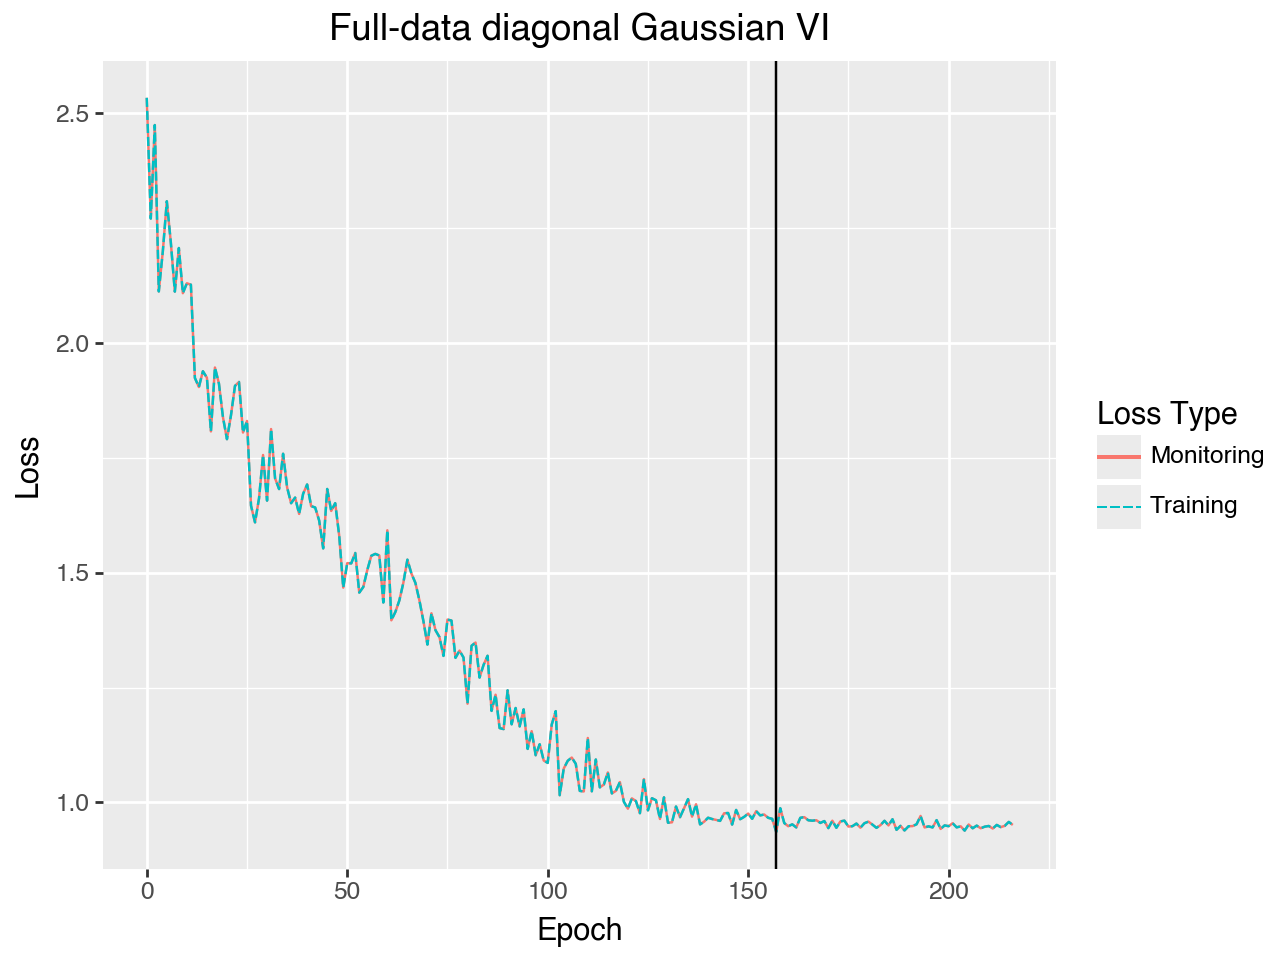

In [8]:
result_full.plot_loss(title="Full-data diagonal Gaussian VI")

## Add a train/test split

For VI, we do not create validation data for the ELBO. The test split is never touched by the optimizer; we keep it for a final predictive check.

In [9]:
split = opt.PositionSplit.from_model(
    model,
    position_keys=["X", "y"],
    share_test=0.1,
    shuffle=True,
    seed=123,
)

pd.DataFrame(
    {
        "part": ["train", "validate", "test"],
        "n": [split.n_train, split.n_validate, split.n_test],
    }
)

,part,n
0,train,216
1,validate,0
2,test,24


## Mini-batches and Adam

For stochastic VI we pass `batch_size`. The default no-validation monitor for mini-batch runs is a weighted average of post-update batch losses across the epoch.

In [10]:
loss_mb = opt.NegElboLoss.mvn_diag(
    model,
    split=split,
    nsamples=3,
    scale=True,
    scale_diag=0.2,
)
mb_schedule = optax.exponential_decay(
    init_value=3e-2,
    transition_steps=60,
    decay_rate=0.95,
    end_value=1e-3,
)
mb_optimizer = opt.Optimizer(
    list(loss_mb.q.parameters),
    optax.adam(mb_schedule),
    identifier="mini_batch_vi_adam",
)

mb_engine = opt.LieselVI(
    model,
    loss=loss_mb,
    batch_size=40,
    optimizers=[mb_optimizer],
    stopper=opt.Stopper(epochs=350, patience=50, rtol=1e-4),
    seed=22,
).build_engine()
mb_engine.show_progress = False

{
    "batching": repr(mb_engine.batches),
    "train_monitor": mb_engine.train_monitor,
    "optimizer_ids": [optimizer.identifier for optimizer in mb_engine.optimizers],
}

{'batching': 'Batches(n=216, batch_size=40, default_axis=0)',
 'train_monitor': 'auto',
 'optimizer_ids': ['mini_batch_vi_adam']}

In [11]:
result_mb = mb_engine.fit()
result_mb

OptimResult(final_epoch=122, best_epoch=72, duration=0.5s)

In [12]:
posterior_mb = mb_engine.loss.vdist.sample(
    jax.random.key(2025),
    sample_shape=(2_000,),
    at_position=result_mb.best_position,
)

beta_samples = np.asarray(posterior_mb["beta"])
sigma_samples = np.exp(np.asarray(posterior_mb["log_sigma"]))

rows = [
    {
        "parameter": f"beta[{i}]",
        "mean": float(beta_samples[:, i].mean()),
        "sd": float(beta_samples[:, i].std()),
        "truth": float(truth),
    }
    for i, truth in enumerate(beta_true)
]
rows.append(
    {
        "parameter": "sigma",
        "mean": float(sigma_samples.mean()),
        "sd": float(sigma_samples.std()),
        "truth": float(sigma_true),
    }
)

pd.DataFrame(rows)

,parameter,mean,sd,truth
0,beta[0],0.686,0.044,0.700
1,beta[1],-1.423,0.038,-1.400
2,sigma,0.606,0.030,0.600


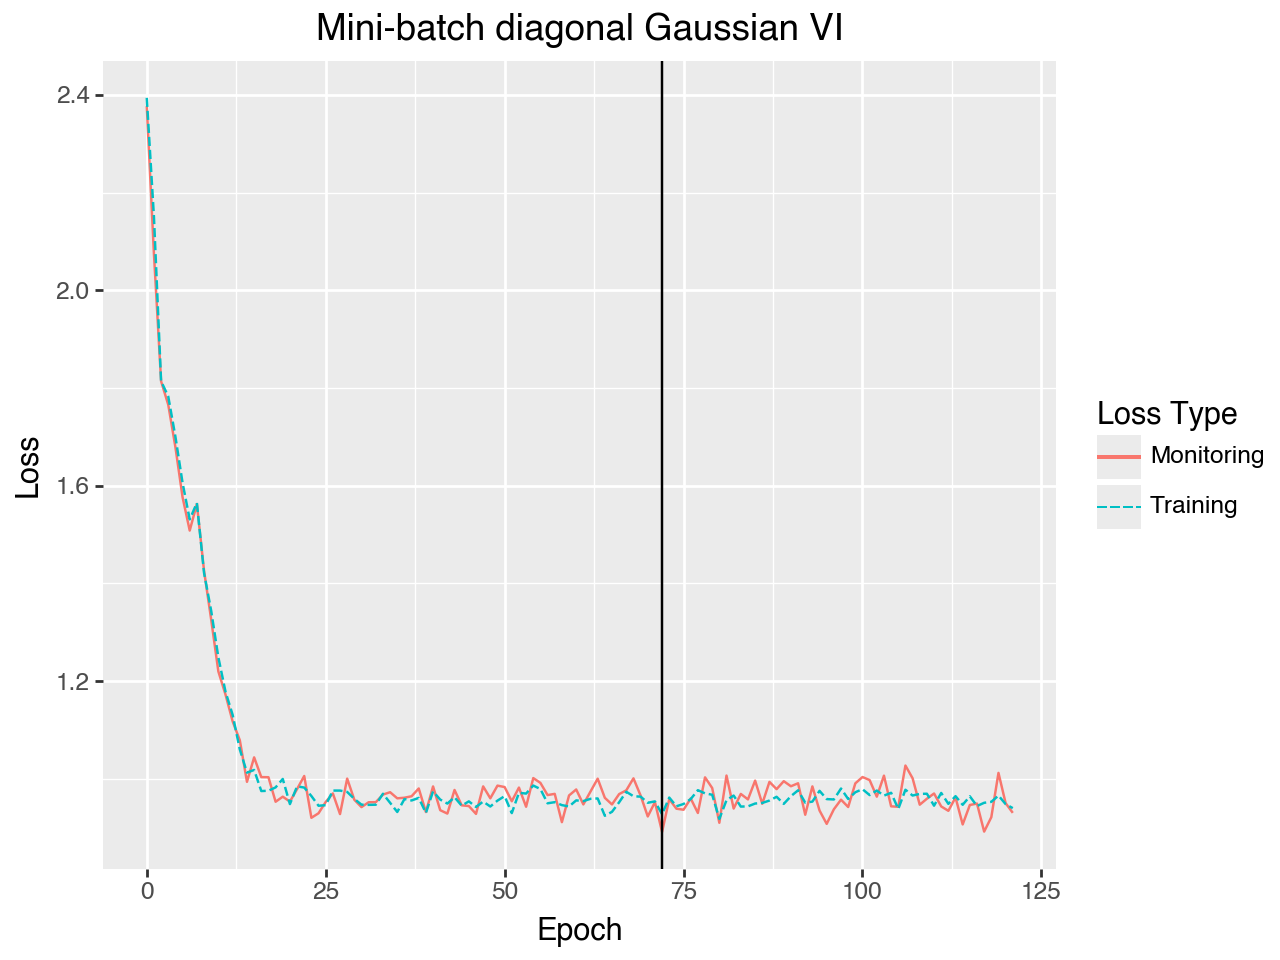

In [13]:
result_mb.plot_loss(title="Mini-batch diagonal Gaussian VI")

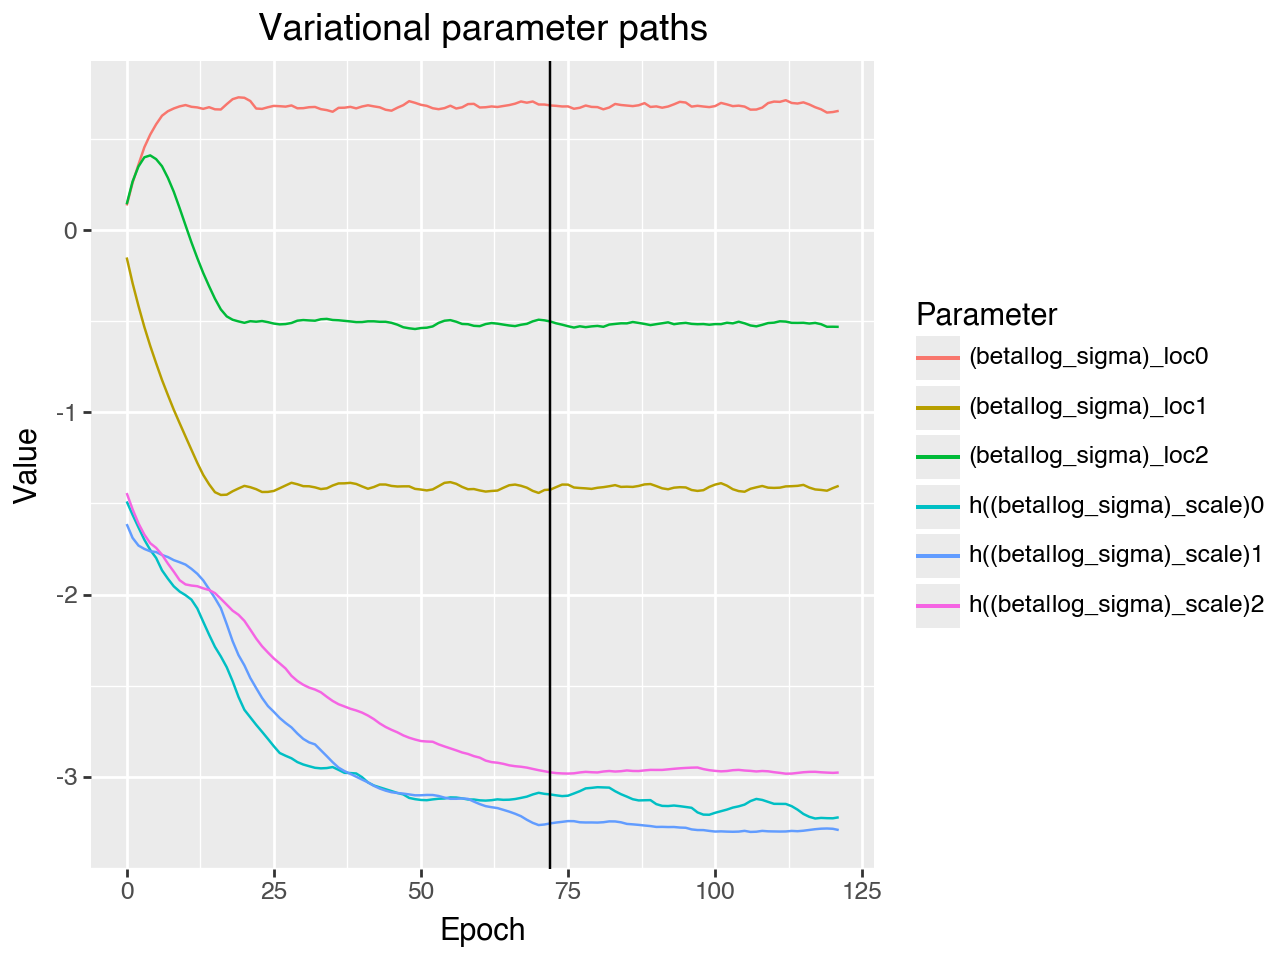

In [14]:
result_mb.plot_params(
    title="Variational parameter paths",
    subset=list(mb_engine.loss.q.parameters),
)

## Held-out predictive check

In [15]:
X_test = np.asarray(split.test["X"])
y_test = np.asarray(split.test["y"])

mu_test_samples = X_test @ beta_samples.T
posterior_mean = mu_test_samples.mean(axis=1)
interval = np.quantile(mu_test_samples, [0.05, 0.95], axis=1)
rmse = np.sqrt(np.mean((posterior_mean - y_test) ** 2))
coverage = np.mean((y_test >= interval[0]) & (y_test <= interval[1]))

pd.DataFrame(
    {
        "best_epoch": [result_mb.best_epoch],
        "final_epoch": [result_mb.final_epoch],
        "test_rmse": [rmse],
        "mean_interval_90pct_coverage": [coverage],
    }
)

,best_epoch,final_epoch,test_rmse,mean_interval_90pct_coverage
0,72,122,0.535,0.125


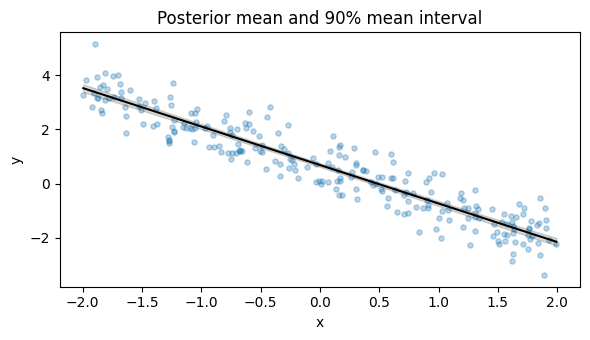

In [16]:
x_grid = np.linspace(x.min(), x.max(), 100)
X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
mu_grid_samples = X_grid @ beta_samples.T
mu_grid_mean = mu_grid_samples.mean(axis=1)
mu_grid_interval = np.quantile(mu_grid_samples, [0.05, 0.95], axis=1)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(x, y, s=14, alpha=0.3)
ax.plot(x_grid, mu_grid_mean, color="black", linewidth=1.5)
ax.fill_between(
    x_grid,
    mu_grid_interval[0],
    mu_grid_interval[1],
    color="black",
    alpha=0.15,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Posterior mean and 90% mean interval")
plt.tight_layout()
plt.show()